<a href="https://colab.research.google.com/github/alex-degarate/DAnalytics/blob/main/After_15/ej15_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

url = "https://github.com/alex-degarate/DAnalytics/raw/refs/heads/main/After_15/"

df_pp_ventas = pd.read_csv( url + "ventas_por_region.csv")

In [11]:
# revisar DF
df_pp_ventas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   fecha     1000 non-null   object
 1   producto  1000 non-null   object
 2   region    1000 non-null   object
 3   ventas    1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


In [12]:
df_pp_ventas.head()

,fecha,producto,region,ventas
0,2025-03-24,Auriculares,Este,$9984.02
1,2024-11-04,Smart TV,Este,$8723.07
2,2025-05-14,Auriculares,Oeste,$11326.45
3,2025-04-21,Smart TV,Centro,$7404.36
4,2025-05-18,Smartphone,Oeste,$9358.53


In [13]:
# convertir texto ventas a float
df_pp_ventas ["ventas"] = df_pp_ventas ["ventas"].str.replace('$','', regex=False)
df_pp_ventas ["ventas"] = df_pp_ventas ["ventas"].astype( "float64")

# convertir text fecha a datetime
df_pp_ventas ["fecha"] = pd.to_datetime( df_pp_ventas ["fecha"])
df_pp_ventas ["fecha"] = df_pp_ventas ["fecha"].dt.strftime("%d/%m/%Y")
df_pp_ventas ["fecha"] = pd.to_datetime( df_pp_ventas ["fecha"])


/tmp/ipython-input-3537654774.py:8: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_pp_ventas ["fecha"] = pd.to_datetime( df_pp_ventas ["fecha"])


In [14]:
print(df_pp_ventas.info() )
print(df_pp_ventas.head() )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   fecha     1000 non-null   datetime64[ns]
 1   producto  1000 non-null   object        
 2   region    1000 non-null   object        
 3   ventas    1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 31.4+ KB
None
       fecha     producto  region    ventas
0 2025-03-24  Auriculares    Este   9984.02
1 2024-11-04     Smart TV    Este   8723.07
2 2025-05-14  Auriculares   Oeste  11326.45
3 2025-04-21     Smart TV  Centro   7404.36
4 2025-05-18   Smartphone   Oeste   9358.53


In [15]:
df_pp_ventas["producto"].unique()

array(['Auriculares', 'Smart TV', 'Smartphone', 'Consola de videojuegos',
       'Notebook'], dtype=object)

In [16]:
df_pp_ventas["region"].unique()

array(['Este', 'Oeste', 'Centro', 'Sur', 'norte'], dtype=object)

In [18]:
#df_pp_ventas[ df_pp_ventas["producto"] == "Auriculares"].
tabla_ventas = (df_pp_ventas.groupby("producto", as_index=False)["ventas"].sum())

tabla_ventas.head()

,producto,ventas
0,Auriculares,1820473.24
1,Consola de videojuegos,1607563.02
2,Notebook,1783246.51
3,Smart TV,1784653.97
4,Smartphone,1704850.39


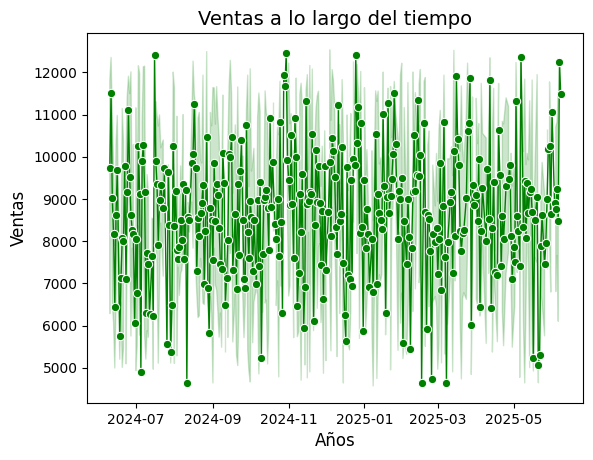

In [7]:

# Gráfico de líneas
sns.lineplot(x='fecha', y='ventas', data=df_pp_ventas, marker='o', color='green',linewidth=1)
plt.title('Ventas a lo largo del tiempo', fontsize=14)
plt.xlabel('Años', fontsize=12)
plt.ylabel('Ventas', fontsize=12)

plt.show()